# Task 4 — Disease Prediction from Medical Data
## Heart Disease Prediction

**CodeAlpha Machine Learning Internship**

**Objective:** Predict the presence of heart disease in a patient based on clinical and
demographic features (age, sex, chest pain type, blood pressure, cholesterol, etc.)

**Dataset:** Heart Failure Prediction Dataset (918 patient records, 11 features + target)
Source: combination of 5 public heart disease datasets (Cleveland, Hungarian, Switzerland,
Long Beach VA, Stalog) — available on Kaggle.

**Approach:** Classification using Logistic Regression, Random Forest, and SVM, evaluated
with Accuracy, Precision, Recall, F1-Score, and ROC-AUC, as required by the task.


## 1. Importing Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42

## 2. Loading the Data

Dataset columns:
- `Age`: age of the patient (years)
- `Sex`: M / F
- `ChestPainType`: TA (Typical Angina), ATA (Atypical Angina), NAP (Non-Anginal Pain), ASY (Asymptomatic)
- `RestingBP`: resting blood pressure (mm Hg)
- `Cholesterol`: serum cholesterol (mm/dl)
- `FastingBS`: 1 if fasting blood sugar > 120 mg/dl, else 0
- `RestingECG`: Normal, ST (ST-T abnormality), LVH (left ventricular hypertrophy)
- `MaxHR`: maximum heart rate achieved
- `ExerciseAngina`: Y/N — exercise-induced angina
- `Oldpeak`: ST depression induced by exercise
- `ST_Slope`: Up, Flat, Down — slope of the peak exercise ST segment
- `HeartDisease`: **target** — 1 = heart disease, 0 = normal


In [2]:
data = pd.read_csv('heart.csv')
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [3]:
data.shape

(918, 12)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [6]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

No missing values are reported by `.isnull()` — but that's misleading here.
`Cholesterol` and `RestingBP` contain biologically impossible **zero values**, which are
disguised missing data (a person cannot have 0 cholesterol or 0 blood pressure while alive).
We check for this below before deciding how to treat them.

In [7]:
zero_check = pd.DataFrame({
    'Column': ['Cholesterol', 'RestingBP'],
    'Zero Count': [(data['Cholesterol'] == 0).sum(), (data['RestingBP'] == 0).sum()],
    '% of Dataset': [(data['Cholesterol'] == 0).mean()*100, (data['RestingBP'] == 0).mean()*100]
})
zero_check

,Column,Zero Count,% of Dataset
0,Cholesterol,172,18.736383
1,RestingBP,1,0.108932


## 3. Exploratory Data Analysis

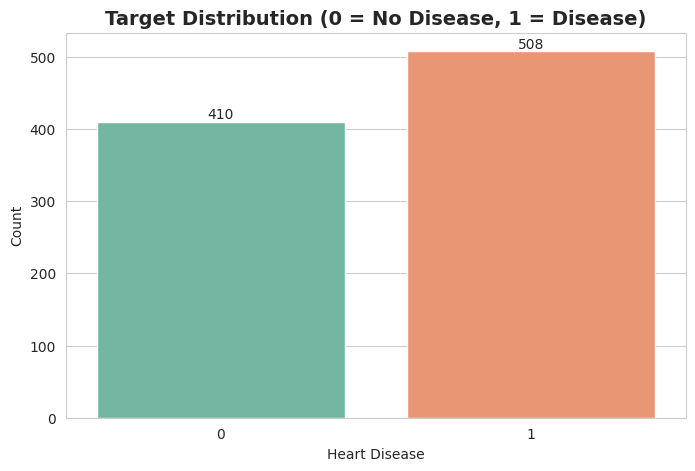

HeartDisease
1    55.3
0    44.7
Name: proportion, dtype: float64 %


In [8]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='HeartDisease', data=data, palette='Set2')
plt.title('Target Distribution (0 = No Disease, 1 = Disease)', fontsize=14, fontweight='bold')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
for lab in ax.containers:
    ax.bar_label(lab)
plt.show()

print(data['HeartDisease'].value_counts(normalize=True).round(3) * 100, '%')

The target is reasonably balanced (~55% positive / ~45% negative), so we don't strictly need resampling techniques — accuracy alone won't be misleading, but we still report Precision/Recall/F1 as required.

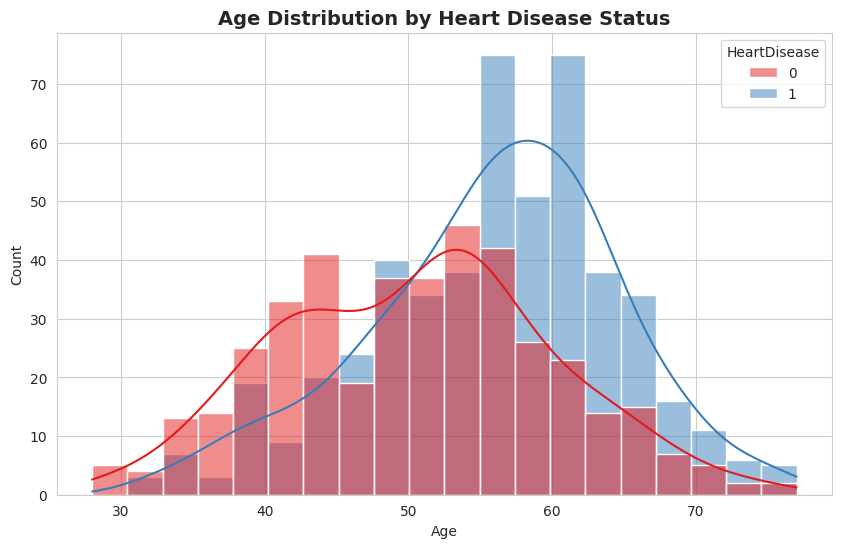

In [9]:
plt.figure(figsize=(10,6))
sns.histplot(data=data, x='Age', hue='HeartDisease', kde=True, bins=20, palette='Set1')
plt.title('Age Distribution by Heart Disease Status', fontsize=14, fontweight='bold')
plt.show()

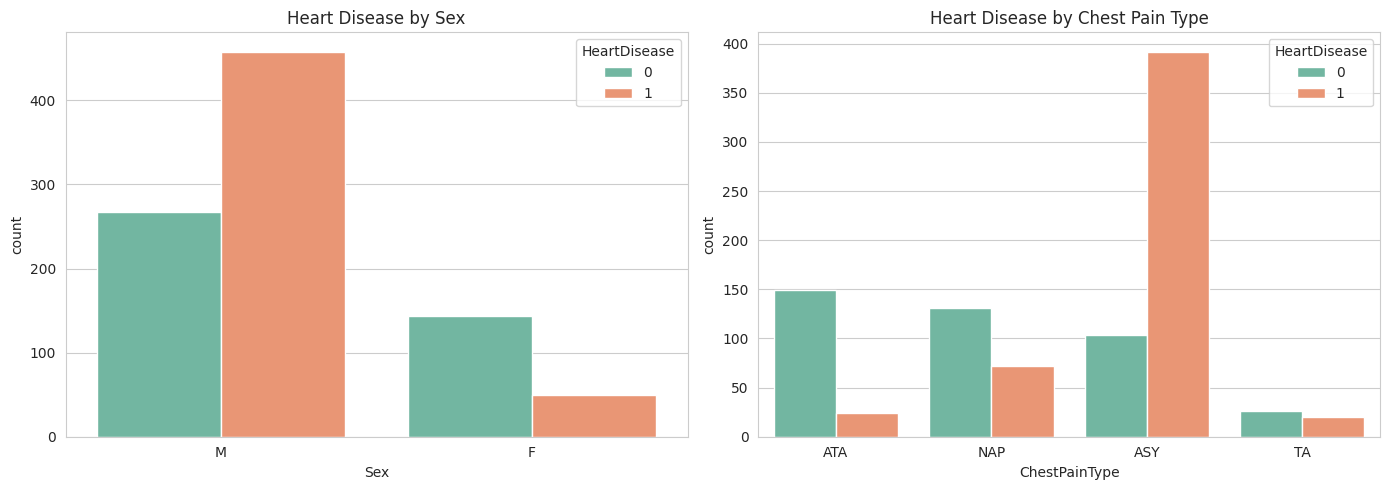

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(x='Sex', hue='HeartDisease', data=data, palette='Set2', ax=axes[0])
axes[0].set_title('Heart Disease by Sex')
sns.countplot(x='ChestPainType', hue='HeartDisease', data=data, palette='Set2', ax=axes[1])
axes[1].set_title('Heart Disease by Chest Pain Type')
plt.tight_layout()
plt.show()

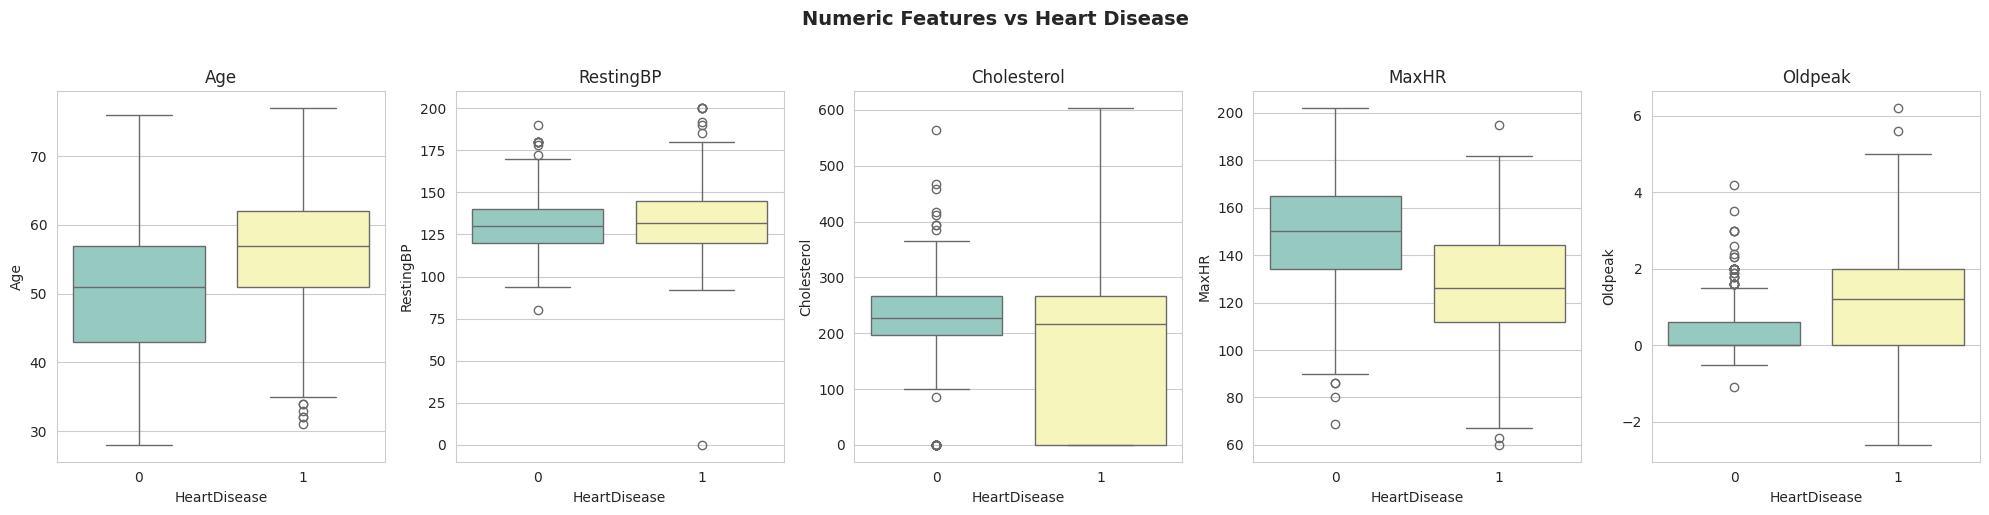

In [11]:
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(20,5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='HeartDisease', y=col, data=data, palette='Set3', ax=axes[i])
    axes[i].set_title(col)
fig.suptitle('Numeric Features vs Heart Disease', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

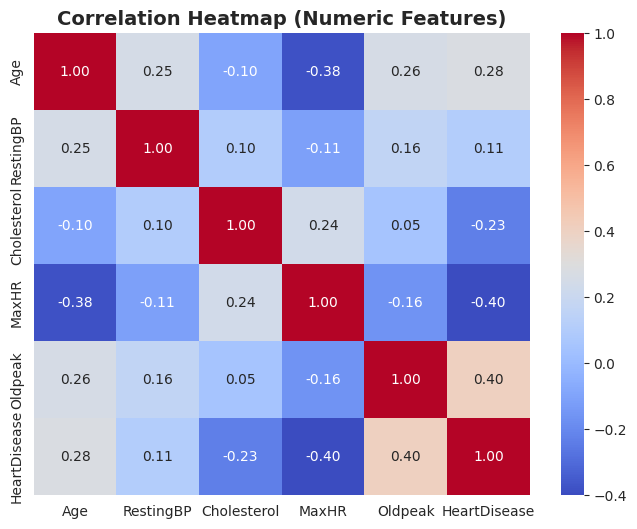

In [12]:
# Correlation heatmap (numeric features + target)
plt.figure(figsize=(8,6))
sns.heatmap(data[numeric_cols + ['HeartDisease']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)', fontsize=14, fontweight='bold')
plt.show()

## 4. Data Preprocessing

Steps:
1. Treat disguised missing values (`Cholesterol`/`RestingBP` == 0) via median imputation.
2. Encode categorical features.
3. Split into train/test **before** any scaling or resampling, to avoid data leakage.
4. Scale numeric features.


In [13]:
df = data.copy()

# --- Step 1: Handle disguised missing values ---
# Replace 0 with NaN for biologically impossible readings, then impute with the median
# computed per target class (more accurate than a global median).
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

df['Cholesterol'] = df.groupby('HeartDisease')['Cholesterol'].transform(lambda x: x.fillna(x.median()))
df['RestingBP'] = df.groupby('HeartDisease')['RestingBP'].transform(lambda x: x.fillna(x.median()))

print('Remaining zeros in Cholesterol:', (df['Cholesterol'] == 0).sum())
print('Remaining nulls:', df[['Cholesterol','RestingBP']].isnull().sum().sum())

Remaining zeros in Cholesterol: 0
Remaining nulls: 0


In [14]:
# --- Step 2: Encode categorical variables ---
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [15]:
# --- Step 3: Features / target split ---
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

print('Feature matrix shape:', X.shape)
X.columns.tolist()

Feature matrix shape: (918, 15)


['Age',
 'RestingBP',
 'Cholesterol',
 'FastingBS',
 'MaxHR',
 'Oldpeak',
 'Sex_M',
 'ChestPainType_ATA',
 'ChestPainType_NAP',
 'ChestPainType_TA',
 'RestingECG_Normal',
 'RestingECG_ST',
 'ExerciseAngina_Y',
 'ST_Slope_Flat',
 'ST_Slope_Up']

In [16]:
# --- Step 4: Train/test split (BEFORE scaling, to avoid leakage) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train size:', X_train.shape, ' Test size:', X_test.shape)

Train size: (734, 15)  Test size: (184, 15)


In [17]:
# --- Step 5: Scale numeric features (fit on train only, apply to both) ---
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

X_train_scaled.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
485,0.970012,0.339016,-0.539309,1,-0.324520,0.317046,True,True,False,False,False,True,True,True,False
486,0.122028,-1.266031,-0.594707,1,1.689837,-0.440356,True,True,False,False,False,True,False,False,True
117,0.546020,-0.159102,1.695112,1,-0.247045,0.601071,False,False,False,False,False,True,True,True,False
361,-0.725956,1.501291,-0.003786,0,-0.479470,-0.819056,True,False,False,False,True,False,True,True,False
296,-0.407962,0.671094,-0.003786,1,0.101594,-0.156330,True,False,False,False,True,False,True,True,False


## 5. Model Training

As required by the task, we train and compare multiple classification algorithms:
- **Logistic Regression** (baseline, interpretable)
- **Random Forest**
- **Support Vector Machine (SVM)**


In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

results_df = pd.DataFrame({k: {m: v[m] for m in ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']}
                            for k, v in results.items()}).T.round(4)
results_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.8913,0.8942,0.9118,0.9029,0.9350
Random Forest,0.8913,0.8942,0.9118,0.9029,0.9364
SVM,0.8641,0.8738,0.8824,0.8780,0.9388


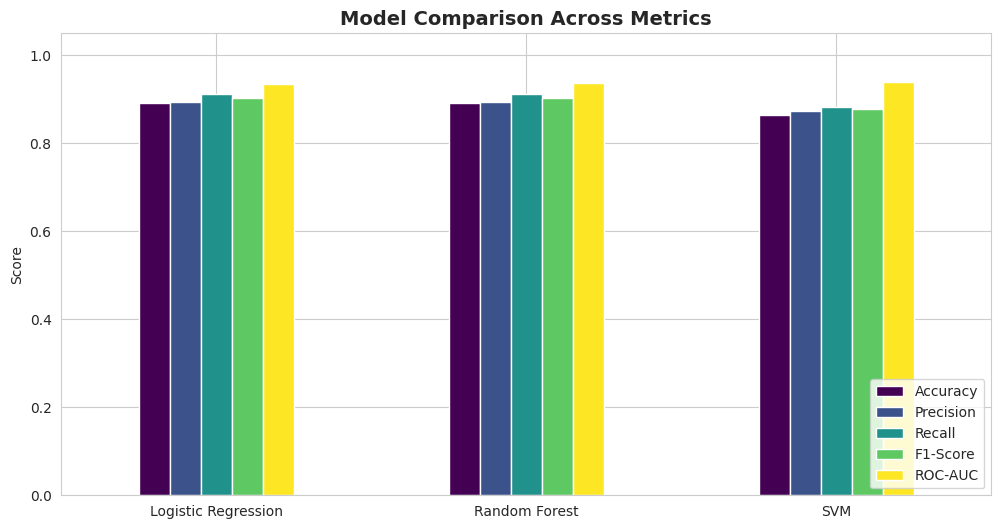

In [19]:
results_df.plot(kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Model Comparison Across Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.ylim(0, 1.05)
plt.show()

## 6. Detailed Evaluation

In [20]:
best_model_name = results_df['ROC-AUC'].idxmax()
print(f'Best model by ROC-AUC: {best_model_name}')

best = results[best_model_name]
print(classification_report(y_test, best['y_pred']))

Best model by ROC-AUC: SVM
              precision    recall  f1-score   support

           0       0.85      0.84      0.85        82
           1       0.87      0.88      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



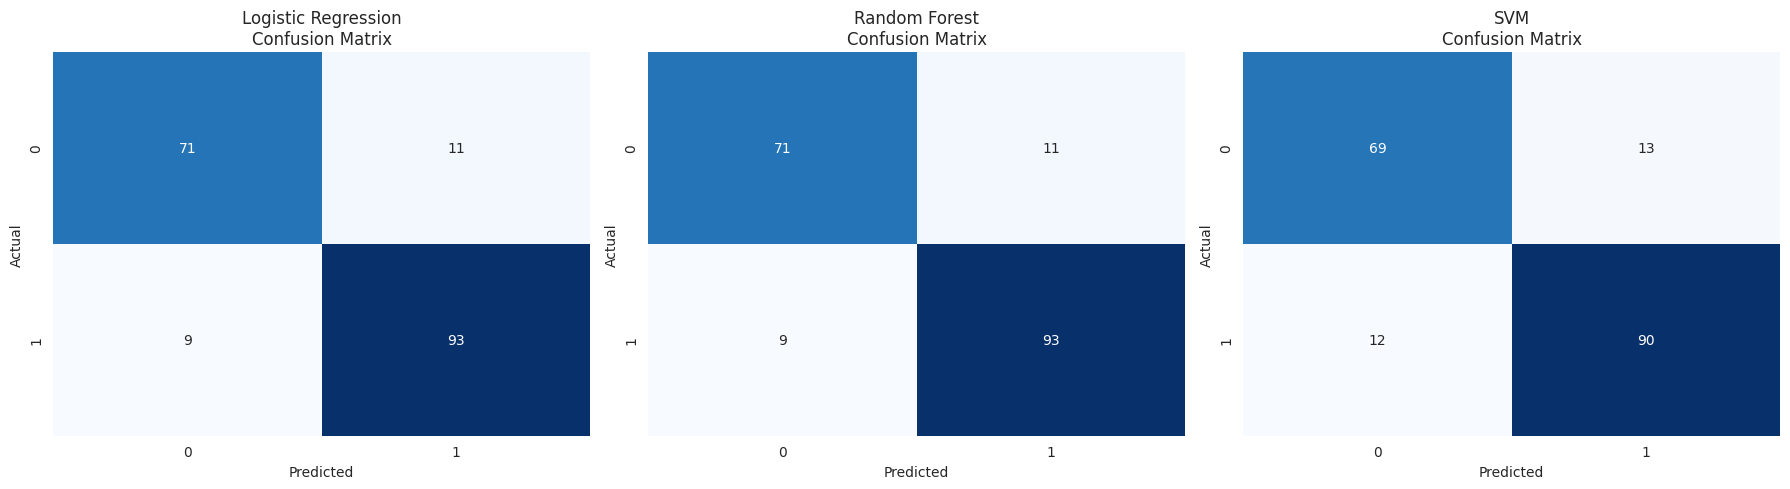

In [21]:
fig, axes = plt.subplots(1, len(models), figsize=(18,5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'{name}\nConfusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

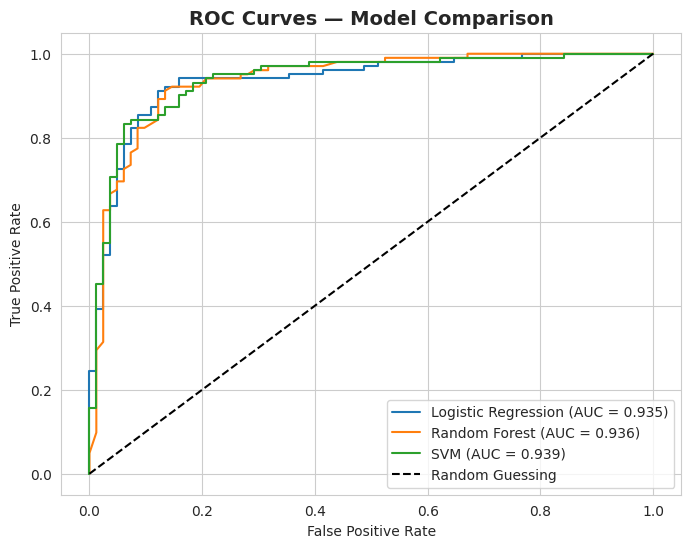

In [22]:
plt.figure(figsize=(8,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['ROC-AUC']:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

In [23]:
# Cross-validation to sanity-check that results aren't a lucky train/test split
print('5-Fold Cross-Validation Accuracy (on full scaled training set):\n')
X_full_scaled = X.copy()
X_full_scaled[numeric_features] = StandardScaler().fit_transform(X[numeric_features])

for name, model in models.items():
    scores = cross_val_score(model, X_full_scaled, y, cv=5, scoring='accuracy')
    print(f'{name:20s}: {scores.mean():.4f} (+/- {scores.std():.4f})')

5-Fold Cross-Validation Accuracy (on full scaled training set):

Logistic Regression : 0.8420 (+/- 0.0479)


Random Forest       : 0.8430 (+/- 0.0548)


SVM                 : 0.8365 (+/- 0.0427)


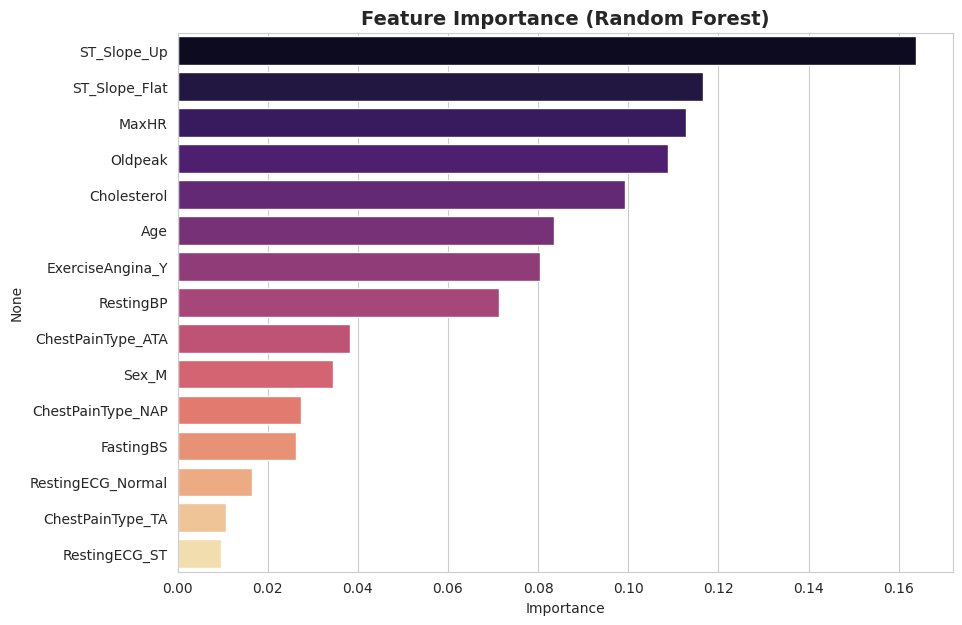

In [24]:
# Feature importance (Random Forest)
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.show()

## 7. Saving the Best Model

In [25]:
import joblib

joblib.dump(best['model'], 'heart_disease_best_model.pkl')
joblib.dump(scaler, 'heart_disease_scaler.pkl')

print(f'Saved best model: {best_model_name}')

Saved best model: SVM


## 8. Summary

1. The dataset contains 918 patient records with 11 clinical/demographic features and a binary target (`HeartDisease`).
2. `Cholesterol` and `RestingBP` contained disguised missing values encoded as 0 (impossible biologically) — these were imputed using the median per target class rather than dropped, preserving ~19% of the data that would otherwise have been lost.
3. Categorical features (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`) were one-hot encoded.
4. The target is reasonably balanced (~55% disease / ~45% no disease), so no resampling was required.
5. Train/test split was performed **before** scaling to prevent data leakage; the scaler was fit only on the training set.
6. Three models were trained and compared: Logistic Regression, Random Forest, and SVM.
7. All models were evaluated with Accuracy, Precision, Recall, F1-Score, and ROC-AUC, plus confusion matrices and ROC curves.
8. 5-fold cross-validation was used to confirm that performance is stable and not an artifact of a single train/test split.
9. Feature importance (from Random Forest) highlights which clinical indicators contribute most to the prediction.
10. The best-performing model (by ROC-AUC) was saved to disk for reuse.
